In [4]:
import numpy as np
import jax.numpy as jnp
from CartPole import *
from Common import *
from Rollout import *
from Model4Dim import *

In [4]:
N = 4000
M = 1000
N_test = 1000

X_train, Y_train, axis_names = collect_data(N)
X_basis = select_basis_centres(X_train, M)
X_test, Y_test, axis_names = collect_data(N_test)

In [11]:
save_jnp_array("data_4/X_train", X_train)
save_jnp_array("data_4/Y_train", Y_train)
save_jnp_array("data_4/X_basis", X_basis)
save_jnp_array("data_4/X_test", X_test)
save_jnp_array("data_4/Y_test", Y_test)

In [5]:
X_train = load_jnp_array("data_4/X_train")
Y_train = load_jnp_array("data_4/Y_train")
X_basis = load_jnp_array("data_4/X_basis")
X_test = load_jnp_array("data_4/X_test")
Y_test = load_jnp_array("data_4/Y_test")

In [5]:
sigma = jnp.tile(jnp.std(X_train, axis=0), (4, 1))
lam = jnp.tile(jnp.power(0.1, 2), (4, 1))
print(sigma)
print(lam)

alpha = fit_alpha(X_train, X_basis, Y_train, sigma[0], lam[0])

[[ 2.899698   2.8531127  1.8023052 11.47251  ]
 [ 2.899698   2.8531127  1.8023052 11.47251  ]
 [ 2.899698   2.8531127  1.8023052 11.47251  ]
 [ 2.899698   2.8531127  1.8023052 11.47251  ]]
[[0.01]
 [0.01]
 [0.01]
 [0.01]]


In [4]:
MSE_vector = jnp.array([
    non_linear_MSE(X_test, Y_test[:, j], X_basis, alpha[:, j], sigma[j]) 
    for j in range(jnp.shape(Y_test)[1])
])
print(MSE_vector)
print(jnp.log(jnp.prod(MSE_vector)))

[0.00186357 0.10041411 0.01432468 1.5563633 ]
-12.387135


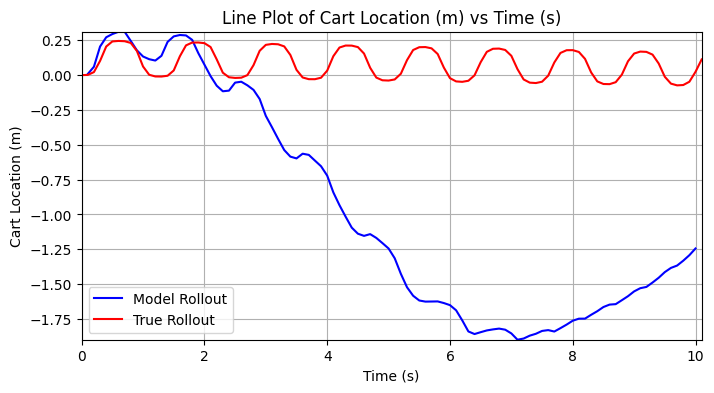

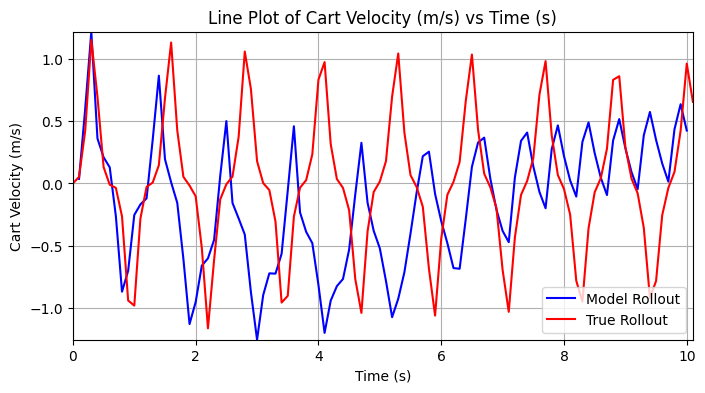

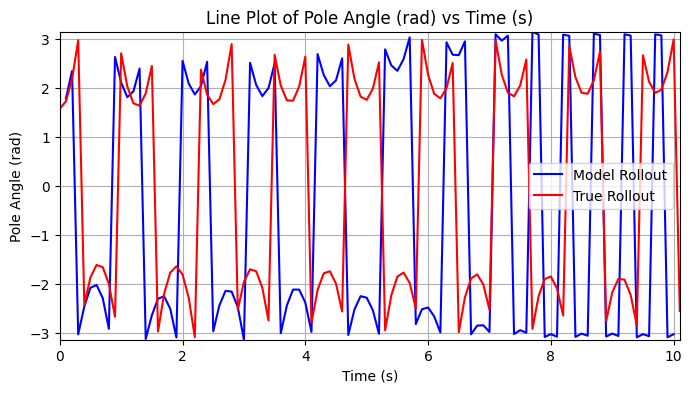

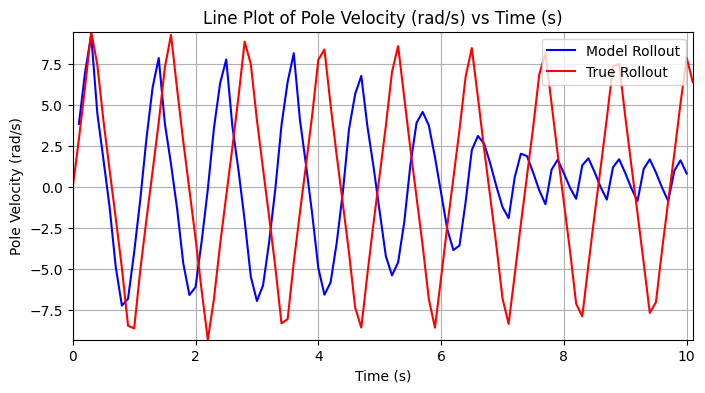

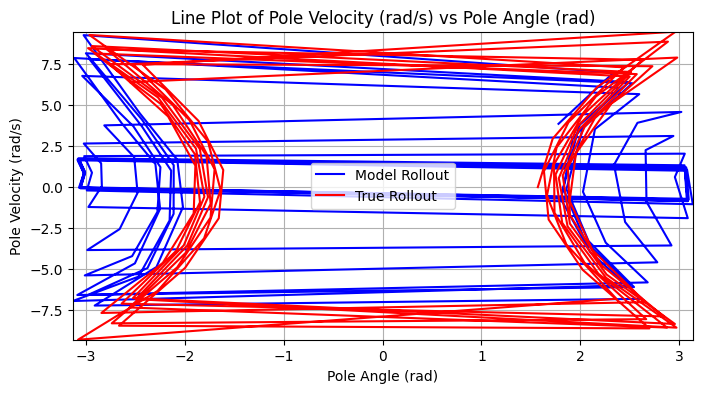

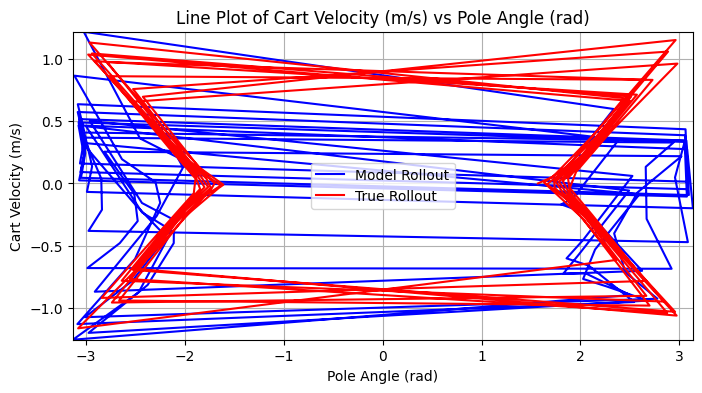

In [5]:
initial_state = jnp.asarray([0,0,jnp.pi/2,0])

state_array = non_linear_rollout(initial_state, X_basis, alpha, sigma, 10)
true_state_array, _ = rollout(initial_state, 10)

axis_names_1 = ['Cart Location (m)','Cart Velocity (m/s)','Pole Angle (rad)','Pole Velocity (rad/s)','Time (s)']
plot_model_graph(state_array, true_state_array, -1, 0, axis_names_1)
plot_model_graph(state_array, true_state_array, -1, 1, axis_names_1)
plot_model_graph(state_array, true_state_array, -1, 2, axis_names_1)
plot_model_graph(state_array, true_state_array, -1, 3, axis_names_1)
plot_model_graph(state_array, true_state_array, 2, 3, axis_names_1)
plot_model_graph(state_array, true_state_array, 2, 1, axis_names_1)

In [8]:
sigma_list = []
lam_list = []
alpha_list = []

for j in range(Y_train.shape[1]):
    sigma_j, lam_j, alpha_j, _ = fit_hyperparameters(X_train, Y_train[:, j], X_basis, X_test, Y_test[:, j])
    sigma_list.append(sigma_j)
    lam_list.append([lam_j])  # keep shape (1,)
    alpha_list.append(alpha_j)

sigma = jnp.vstack(sigma_list)
lam = jnp.array(lam_list)
alpha = jnp.stack(alpha_list, axis=1)


In [9]:
save_jnp_array("data_4/sigma", sigma)
save_jnp_array("data_4/lam", lam)
save_jnp_array("data_4/alpha", alpha)

In [8]:
sigma = load_jnp_array("data_4/sigma")
lam = load_jnp_array("data_4/lam")
alpha = load_jnp_array("data_4/alpha")

In [19]:
print(sigma)
print(lam)

[[ 3.4660337   3.4204667   2.4560387  11.660463  ]
 [ 6.3233128   6.656609    0.5586988  12.431503  ]
 [ 4.8804874   5.2821093   3.2189283  11.828431  ]
 [10.878386   12.084133    0.46399164 14.351562  ]]
[[0.        ]
 [0.28504202]
 [0.2759427 ]
 [0.        ]]


In [13]:
MSE_vector = jnp.array([
    non_linear_MSE(X_test, Y_test[:, j], X_basis, alpha[:, j], sigma[j]) 
    for j in range(jnp.shape(Y_test)[1])
])
print(MSE_vector)
print(jnp.log(jnp.prod(MSE_vector)))

[0.00170484 0.04319078 0.01069513 0.18084428]
-15.764498


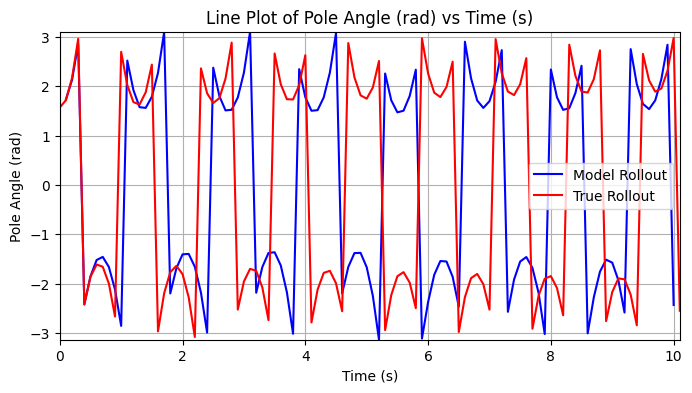

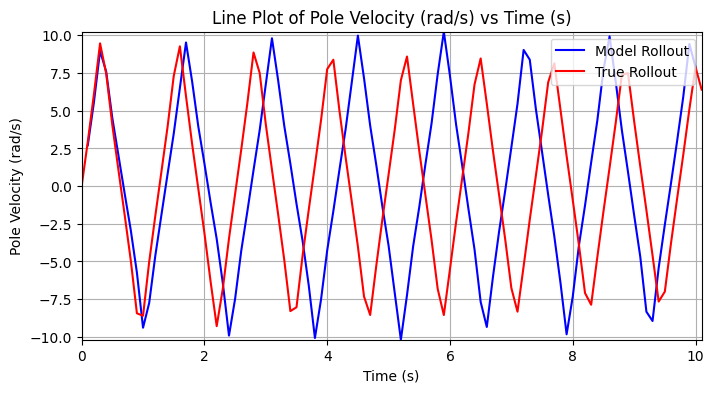

In [14]:
initial_state = [0.0, 0.0, jnp.pi/2, 0]

state_array = non_linear_rollout(initial_state, X_basis, alpha, sigma, 10)
true_state_array, _ = rollout(initial_state, 10)

axis_names_1 = ['Cart Location (m)','Cart Velocity (m/s)','Pole Angle (rad)','Pole Velocity (rad/s)','Time (s)']
#plot_model_graph(state_array, true_state_array, -1, 0, axis_names_1)
#plot_model_graph(state_array, true_state_array, -1, 1, axis_names_1)
plot_model_graph(state_array, true_state_array, -1, 2, axis_names_1)
plot_model_graph(state_array, true_state_array, -1, 3, axis_names_1)
#plot_model_graph(state_array, true_state_array, 2, 3, axis_names_1)
#plot_model_graph(state_array, true_state_array, 2, 1, axis_names_1)

<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=58725ef8-9a26-4e31-9e4c-5d3613b1a28f' target="_blank">
 </img>
Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>